# Anderson Localization in a Disordered Tight-Binding Chain

This notebook builds a one-dimensional tight-binding chain with random onsite disorder. Disorder localizes eigenstates, which can be measured by the inverse participation ratio (IPR):

$$\mathrm{IPR}(\psi)=\sum_i |\psi_i|^4.$$

A localized state has much larger IPR than an extended state.


## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a disordered one-dimensional tight-binding chain.

**QSVT implementation.** It uses an energy-window polynomial filter around a localized eigenstate. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact eigenvectors and inverse participation ratios validate localization. The QSVT angle is selective spectral filtering of disordered Hamiltonians where full diagonalization becomes expensive.


## Variable definitions

- `n_sites`: number of lattice sites.
- `hopping`: nearest-neighbor hopping amplitude.
- `disorder_strength`: strength of random onsite disorder.
- `SEED`, `rng`: reproducible random-number setup.
- `onsite`: random onsite potential.
- `H`: disordered tight-binding Hamiltonian.
- `eigenvalues`, `eigenvectors`: exact disordered spectrum and eigenvectors.
- `ipr`: inverse participation ratios of disordered eigenstates.
- `localized_index`, `localized_state`: most localized eigenstate and its index.
- `clean`, `clean_vectors`, `clean_ipr`: clean-chain reference Hamiltonian, eigenvectors, and IPRs.
- `center_energy`: energy around which the localization filter is centered.
- `scale`: spectral scale for rescaling.
- `A`: rescaled Hamiltonian.
- `fit_x`, `width`, `coeffs`: fitting grid, filter width, and polynomial coefficients.
- `soft_projector`: polynomial spectral-window operator.
- `mode_filter_values`: polynomial filter values on exact eigenvalues.
- `filtered_weight`: diagonal weights from the filter.
- `peak_site`: site with largest filtered weight.
- `fig`, `axes`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.polynomials import eval_polynomial
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_sites = 32
hopping = 1.0
disorder_strength = 2.8
SEED = 0
rng = np.random.default_rng(SEED)
onsite = disorder_strength * rng.uniform(-1.0, 1.0, n_sites)

H = np.diag(onsite)
for i in range(n_sites - 1):
    H[i, i + 1] = H[i + 1, i] = -hopping

eigenvalues, eigenvectors = eigh_hermitian(H)
ipr = np.sum(np.abs(eigenvectors) ** 4, axis=0)
localized_index = int(np.argmax(ipr))
localized_state = eigenvectors[:, localized_index]

clean = np.zeros_like(H)
for i in range(n_sites - 1):
    clean[i, i + 1] = clean[i + 1, i] = -hopping
_, clean_vectors = eigh_hermitian(clean)
clean_ipr = np.sum(np.abs(clean_vectors) ** 4, axis=0)

print(f"Localized IPR: {ipr[localized_index]}")
print(f"Maximum Clean IPR: {np.max(clean_ipr)}")

Localized IPR: 0.6321472059662562
Maximum Clean IPR: 0.045454545454545796


## Polynomial energy-window filter

A Gaussian polynomial centered on the most localized eigenvalue approximately selects that localized state from the full Hamiltonian spectrum.


In [3]:
center_energy = eigenvalues[localized_index]
scale = np.max(np.abs(eigenvalues - center_energy))
A = (H - center_energy * np.eye(n_sites)) / scale

fit_x = np.linspace(-1.0, 1.0, 1201)
width = 0.16
coeffs = np.polynomial.polynomial.polyfit(fit_x, np.exp(-((fit_x / width) ** 2)), 28)
soft_projector = apply_polynomial_to_hermitian(A, coeffs)
mode_filter_values = eval_polynomial(coeffs, (eigenvalues - center_energy) / scale)
filtered_weight = np.real(np.diag(soft_projector))
filtered_weight = filtered_weight / np.sum(filtered_weight)

peak_site = int(np.argmax(np.abs(localized_state) ** 2))
print(f"Peak Site [site index]: {peak_site}")
print(f"Filtered Weight at Peak Site [probability]: {filtered_weight[peak_site]}")

Peak Site [site index]: 14
Filtered Weight at Peak Site [probability]: 0.10072442254521352


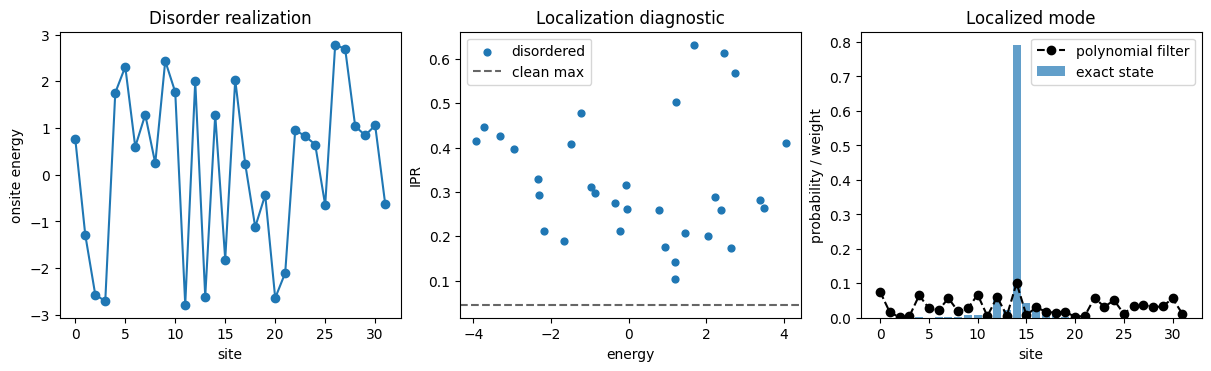

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.2), constrained_layout=True)
site = np.arange(n_sites)

axes[0, 0].plot(site, onsite, "o-")
axes[0, 0].set_xlabel("site")
axes[0, 0].set_ylabel("onsite energy")
axes[0, 0].set_title("disorder realization")

axes[0, 1].scatter(eigenvalues, ipr, s=24, label="disordered")
axes[0, 1].scatter(
    [center_energy],
    [ipr[localized_index]],
    s=70,
    color="tab:red",
    label="selected state",
)
axes[0, 1].axhline(np.max(clean_ipr), color="0.4", linestyle="--", label="clean max")
axes[0, 1].set_xlabel("energy")
axes[0, 1].set_ylabel("IPR")
axes[0, 1].set_title("localization diagnostic")
axes[0, 1].legend(frameon=False)

axes[1, 0].plot(eigenvalues, mode_filter_values, "o")
axes[1, 0].axvline(center_energy, color="tab:red", linestyle="--")
axes[1, 0].set_xlabel("energy")
axes[1, 0].set_ylabel("polynomial window value")
axes[1, 0].set_title("energy-window filter")
axes[1, 0].set_ylim(-0.05, 1.05)

axes[1, 1].bar(site, np.abs(localized_state) ** 2, alpha=0.7, label="exact state")
axes[1, 1].plot(site, filtered_weight, "o--", color="black", label="polynomial filter")
axes[1, 1].axvline(peak_site, color="tab:red", alpha=0.4)
axes[1, 1].set_xlabel("site")
axes[1, 1].set_ylabel("probability / weight")
axes[1, 1].set_title("localized mode and filtered weight")
axes[1, 1].legend(frameon=False)

fig.suptitle("Anderson localization and QSVT-style spectral filtering")
plt.show()

## Validation

Compact checks for disorder-induced localization and the energy-window filter.


In [5]:
assert ipr[localized_index] > 0.25
assert ipr[localized_index] > 5.0 * np.max(clean_ipr)
assert peak_site == int(np.argmax(filtered_weight))
assert filtered_weight[peak_site] > 0.08

print(f"localized_energy [hopping units]: {center_energy:.4f}")
print(f"localized_ipr: {ipr[localized_index]:.4f}")
print(f"clean_max_ipr: {np.max(clean_ipr):.4f}")
print(f"peak_site_filter_weight [probability]: {filtered_weight[peak_site]:.4f}")
print("validation: passed")

localized_energy [hopping units]: 1.6901
localized_ipr: 0.6321
clean_max_ipr: 0.0455
peak_site_filter_weight [probability]: 0.1007
validation: passed
